<div style="text-align:center; background:#2e2e2e; padding:32px 20px">
    <div style="font-size:46px; font-weight:bold; color:#f4f4ef; letter-spacing:4px; text-transform:uppercase">
        Sanghelios
    </div>
    <div style="font-size:17px; color:#888; margin-top:10px; letter-spacing:3px; text-transform:uppercase">
        Parte 1 — EDA y Preprocesamiento
    </div>
    <div style="font-size:17px; color:#666; margin-top:14px; letter-spacing:1px">
        Autor: Jerónimo Hoyos Botero &nbsp;|&nbsp; Creado: Mayo 2026 &nbsp;|&nbsp; Última actualización: Mayo 2026
    </div>
</div>

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Configuración
</div>

<div style="background:#f5f3e8; padding:12px 16px; border:0.5px solid #d8d3b8; border-radius:4px; font-size:16px; color:#555240">
    <b> Ajustes del notebook </b>
</div>

In [188]:
# Automatically reload local modules before each cell run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div style="background:#f5f3e8; padding:12px 16px; border:0.5px solid #d8d3b8; border-radius:4px; font-size:16px; color:#555240">
    <b> Importaciones </b>
</div>

In [189]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import missingno as msno
# Import zscore function
from scipy.stats import zscore
import numpy as np
# Utils
import math
import re
import unicodedata
from pyod.models.mad import MAD

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Carga de Datos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    <b> Cargar los datos mediante los csv descargados. </b>
</div>

In [190]:
paths = {
    "banco_sangre": r"..\data\raw\banco_sangre.csv",
    "defunciones": r"..\data\raw\defunciones.csv",
    "atenciones": r"..\data\raw\atenciones.csv"
}

dataframes = {}

for var_name, file in paths.items():
    print(f"Loading data from: {file}")
    try:
        dataframes[var_name] = pd.read_csv(file, low_memory=False)
        print(f"'{var_name}' loaded successfully. Shape: {dataframes[var_name].shape}")
    except FileNotFoundError:
        print(f"Error: File not found → {file}")
        dataframes[var_name] = None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        dataframes[var_name] = None
    except pd.errors.ParserError:
        print("Error: The file content could not be parsed.")
        dataframes[var_name] = None
    except PermissionError:
        print("Error: Permission denied when accessing the file.")
        dataframes[var_name] = None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        dataframes[var_name] = None

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones  = dataframes["defunciones"]
df_atenciones   = dataframes["atenciones"]

print("\nDimensiones de los DataFrames:")
print("Banco:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Atenciones:", df_atenciones.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\raw\banco_sangre.csv
'banco_sangre' loaded successfully. Shape: (35840, 11)
Loading data from: ..\data\raw\defunciones.csv
'defunciones' loaded successfully. Shape: (5094, 26)
Loading data from: ..\data\raw\atenciones.csv
'atenciones' loaded successfully. Shape: (221203, 12)

Dimensiones de los DataFrames:
Banco:       (35840, 11)
Defunciones: (5094, 26)
Atenciones: (221203, 12)


<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">
    Preparación de Datos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    <b> Funciones para el ajuste de los 3 dataframes. </b>
</div>

In [191]:
def explorar_df(nombre, df):
    print(f"\n{nombre}  —  {df.shape[0]:,} filas × {df.shape[1]} columnas")

    info = pd.DataFrame({
        "dtype":   df.dtypes.astype(str),
        "nulos":   df.isna().sum(),
        "% nulos": (df.isna().mean()*100).round(1),
        **{f"ej {i+1}": df.iloc[i] for i in range(min(5, len(df)))},
    })

    display(info)

In [192]:
def estandarizar_columnas(df):
    def limpiar(col):
        col = unicodedata.normalize("NFKD", col)
        col = col.encode("ascii", "ignore").decode() 
        col = col.strip().lower()
        col = re.sub(r"[^a-z0-9\s]", " ", col)       
        col = re.sub(r"\s+", "_", col).strip("_")    
        return col

    nuevos = {col: limpiar(col) for col in df.columns}
    for viejo, nuevo in nuevos.items():
        if viejo != nuevo:
            print(f"  {viejo!r:35} → {nuevo!r}")

    return df.rename(columns=nuevos)

In [193]:
def estandarizar_etiquetas(etiqueta):
    if pd.isna(etiqueta):
        return etiqueta  
    return (
        str(etiqueta)
        .strip()
        .lower()
        .replace("-", "_")
        .replace("/", "_")
        .replace(" ", "_")
    )

In [194]:
def boxplots_numericas(df):
    numericas = df.select_dtypes(include="number").columns
    n = len(numericas)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numericas):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor="#d0e7fa"),
                   medianprops=dict(color="#185FA5", linewidth=2))
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xticks([]) 
    plt.tight_layout()
    plt.show()


In [195]:
def histogramas_numericas(df):
    numericas = df.select_dtypes(include="number").columns
    n = len(numericas)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numericas):
        ax.hist(df[col].dropna(), bins=30, color="#d0e7fa",
                edgecolor="#185FA5", linewidth=0.5)
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

<div style="background:#2e2e2e; color:#f4f4ef; padding:13px 18px; letter-spacing:2px; text-transform:uppercase; font-size:18px; font-weight:bold; border-left:3px solid #888">Bancos de Sangre</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Exploración general para ver problemas obvios del dataframe.
</div>

In [196]:
explorar_df("Banco", df_banco_sangre)


Banco  —  35,840 filas × 11 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
ANO,int64,0,0.0,2020,2020,2020,2020,2020
TRIMESTRE,int64,0,0.0,4,1,1,1,1
FECHA EXTRACCION,str,0,0.0,28/12/2020,01/02/2020,01/02/2020,01/02/2020,01/02/2020
RH,str,41,0.1,0+,0+,0+,0+,0+
BARRIO,str,7788,21.7,POPULAR 1,20 DE JULIO,20 DE JULIO,20 DE JULIO,20 DE JULIO
CIUDAD,str,0,0.0,MEDELLIN,MEDELLIN,MEDELLIN,MEDELLIN,MEDELLIN
EDAD,float64,2,0.0,41.0,43.0,43.0,44.0,44.0
ESTATURA,float64,79,0.2,NaN,1.74,1.74,1.6,1.6
FECHA NACIMIENTO,str,2,0.0,1982 Jan 01 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Apr 21 12:00:00 AM,1979 Apr 21 12:00:00 AM
PESO,float64,41,0.1,NaN,80.0,80.0,86.0,86.0


In [197]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ["RH","BARRIO","CIUDAD","SEXO"]

for col in cols_cat:
    print(f'Columna {col}: {df_banco_sangre[col].nunique()} subniveles')

Columna RH: 8 subniveles
Columna BARRIO: 1274 subniveles
Columna CIUDAD: 28 subniveles
Columna SEXO: 2 subniveles


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Todas las columnas categóricas tienen más de 1 subnivel.
</div>

In [198]:
df_banco_sangre.describe()

,ANO,TRIMESTRE,EDAD,ESTATURA,PESO
count,35840.000000,35840.000000,35838.000000,35761.000000,35799.000000
mean,2021.828599,2.387249,37.713070,1.663522,73.329004
std,1.569845,1.118653,12.497798,0.089134,13.517872
min,2020.000000,1.000000,14.000000,1.000000,50.000000
25%,2021.000000,1.000000,27.000000,1.600000,63.000000
50%,2022.000000,2.000000,36.000000,1.660000,72.000000
75%,2023.000000,3.000000,47.000000,1.730000,81.000000
max,2025.000000,4.000000,104.000000,2.030000,171.000000


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Todas las columnas numéricas tienen desviaciones estándar ("std") diferentes de cero, lo que indica que no tienen un único valor.
</div>

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Estandarizando nombres y etiquetas
</div>

In [199]:
df_banco_sangre = estandarizar_columnas(df_banco_sangre)

  'ANO'                               → 'ano'
  'TRIMESTRE'                         → 'trimestre'
  'FECHA EXTRACCION'                  → 'fecha_extraccion'
  'RH'                                → 'rh'
  'BARRIO'                            → 'barrio'
  'CIUDAD'                            → 'ciudad'
  'EDAD'                              → 'edad'
  'ESTATURA'                          → 'estatura'
  'FECHA NACIMIENTO'                  → 'fecha_nacimiento'
  'PESO'                              → 'peso'
  'SEXO'                              → 'sexo'


In [200]:
# Define categorical columns to standardize labels
columnas_para_estandarizar = ["barrio", "ciudad", "sexo"]

# Apply standardization of categorical labels
for index in columnas_para_estandarizar:
    df_banco_sangre[index] = df_banco_sangre[index].apply(estandarizar_etiquetas)

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de Duplicados
</div>

In [201]:
exactos = df_banco_sangre.duplicated().sum()
por_nacimiento_extraccion_rh = df_banco_sangre.duplicated(
    subset=["fecha_nacimiento", "fecha_extraccion", "rh"]
).sum()
total = len(df_banco_sangre)

resumen = pd.DataFrame({
    "Tipo de duplicado": ["Exactos (todas las columnas)", "Por fecha_nacimiento + fecha_extraccion + rh"],
    "Cantidad": [exactos, por_nacimiento_extraccion_rh],
    "%": [round(exactos / total * 100, 1), round(por_nacimiento_extraccion_rh / total * 100, 1)]
})

resumen

,Tipo de duplicado,Cantidad,%
0,Exactos (todas las columnas),1622,4.5
1,Por fecha_nacimiento + fecha_extraccion + rh,1746,4.9


<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se encontraron <b>4.5%</b> de duplicados totales y <b>4.9%</b> duplicados por  fecha_nacimiento + fecha_extraccion + rh. Dada la baja probabilidad de estos duplicados serán eliminados.
</div>

In [202]:
df_banco_sangre = df_banco_sangre.drop_duplicates(subset=["fecha_nacimiento", "fecha_extraccion", "rh"])

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Selección de Variables
</div>

<div style="background:#f7f7f3; padding:16px 20px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:15px; color:#2e2e2e">
    La siguiente tabla muestra que variables usaremos para el proyecto: <br> <br>
    <table style="width:100%; border-collapse:collapse; font-size:13px;">
        <thead>
            <tr style="background:#2e2e2e; color:#f4f4ef;">
                <th style="text-align:left; padding:8px 10px; font-weight:500;">Variable</th>
                <th style="text-align:left; padding:8px 10px; font-weight:500;">Descripción</th>
                <th style="text-align:center; padding:8px 10px; font-weight:500;">Incluir</th>
                <th style="text-align:left; padding:8px 10px; font-weight:500;">Justificación</th>
            </tr>
        </thead>
        <tbody>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Año</td>
                <td style="padding:7px 10px;">Año de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✗</td>
                <td style="padding:7px 10px;">Redundante con Fecha Extracción, de la cual se puede derivar.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Trimestre</td>
                <td style="padding:7px 10px;">Trimestre de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✗</td>
                <td style="padding:7px 10px;">Derivable de Fecha Extracción; puede re-crearse en feature engineering.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Fecha Extracción</td>
                <td style="padding:7px 10px;">Fecha de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Permite identificar estacionalidad y tendencias de volumen a lo largo del tiempo.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">RH</td>
                <td style="padding:7px 10px;">Grupo y factor RH del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Determina compatibilidad; esencial para modelar escasez por tipo de sangre.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Barrio</td>
                <td style="padding:7px 10px;">Barrio de residencia del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Permite segmentar geográficamente el perfil del donante e identificar zonas de alta/baja donación.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Ciudad</td>
                <td style="padding:7px 10px;">Ciudad de residencia del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Permite analizar patrones de donación a nivel de ciudad y proyectar volumen por región.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Edad</td>
                <td style="padding:7px 10px;">Edad del donante al momento de la donación</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Variable clave del perfil del donante.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Fecha Nacimiento</td>
                <td style="padding:7px 10px;">Fecha de nacimiento del donante</td>
                <td style="text-align:center; padding:7px 10px;">✗</td>
                <td style="padding:7px 10px;">Redundante con Edad.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4; background:#fafaf9;">
                <td style="padding:7px 10px;">Peso</td>
                <td style="padding:7px 10px;">Peso del donante en kg</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Determina el volumen máximo extraíble por donación; relevante para estimar disponibilidad real de sangre.</td>
            </tr>
            <tr style="border-bottom:0.5px solid #e8e8e4;">
                <td style="padding:7px 10px;">Estatura</td>
                <td style="padding:7px 10px;">Estatura del donante en cm</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Junto con el peso permite calcular el IMC.</td>
            </tr>
            <tr>
                <td style="padding:7px 10px;">Sexo</td>
                <td style="padding:7px 10px;">Sexo biológico del donante</td>
                <td style="text-align:center; padding:7px 10px;">✓</td>
                <td style="padding:7px 10px;">Variable clave del perfil del donante.</td>
            </tr>
        </tbody>
    </table>
</div>

In [203]:
columnas_originales_seleccionadas = ['fecha_extraccion', 'rh', 'barrio', 'ciudad','edad', 'estatura', 'peso', 'sexo']
df_banco_sangre = df_banco_sangre[columnas_originales_seleccionadas]

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Filtrado de Población Objetivo
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Los requisitos para donar sangre según la <a href="https://www.cruzrojacolombiana.org/banco-de-sangre/dona-sangre" target="_blank" rel="noopener noreferrer">Cruz Roja Colombiana</a> son:
    <ul style="margin:8px 0 0 20px;">
        <li style="margin:4px 0;">Pesar más de 50 kg</li>
        <li style="margin:4px 0;">Edad entre 18 y 65 años</li>
    </ul>
</div>

In [204]:
df_banco_sangre = df_banco_sangre[
    (df_banco_sangre["peso"] > 50) &
    (df_banco_sangre["edad"] >= 18) &
    (df_banco_sangre["edad"] <= 65)
].copy()

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de tipos de datos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se van identificar los tipos de datos no adecuados.
</div>

In [205]:
df_banco_sangre.dtypes

fecha_extraccion        str
rh                      str
barrio                  str
ciudad                  str
edad                float64
estatura            float64
peso                float64
sexo                    str
dtype: object

In [206]:
# Un formato estandar para fechas y asegurarnos que edad es un entero
df_banco_sangre["fecha_extraccion"] = pd.to_datetime(df_banco_sangre["fecha_extraccion"], format="%d/%m/%Y").dt.date
df_banco_sangre["edad"] = df_banco_sangre["edad"].astype(int)

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de errores tipográficos en variables categóricos
</div>

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    Se analizará si existen subniveles con diferente nombre pero mismo significado, excluyendo barrio debido a su alta cantidad de nombres distintos.
</div>

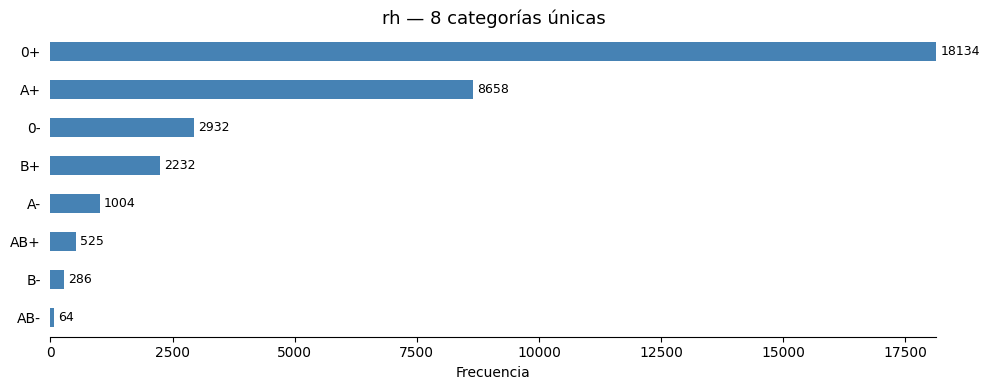

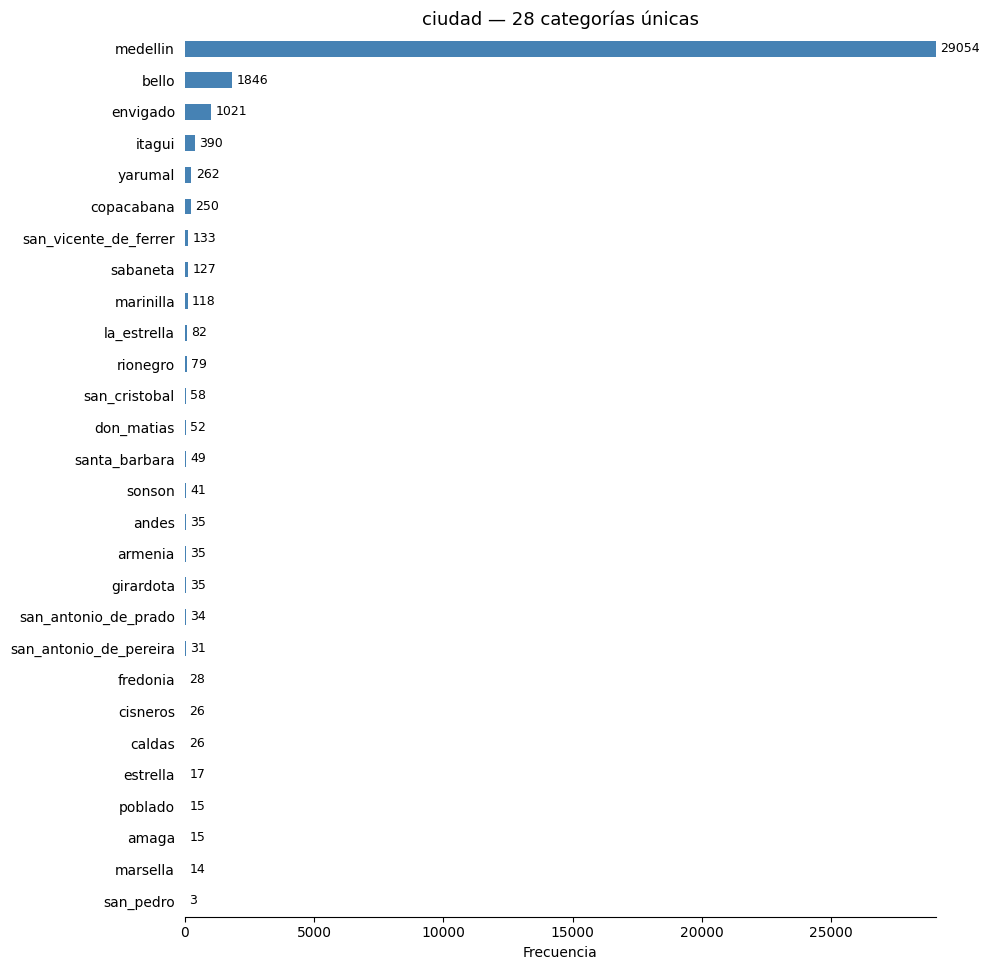

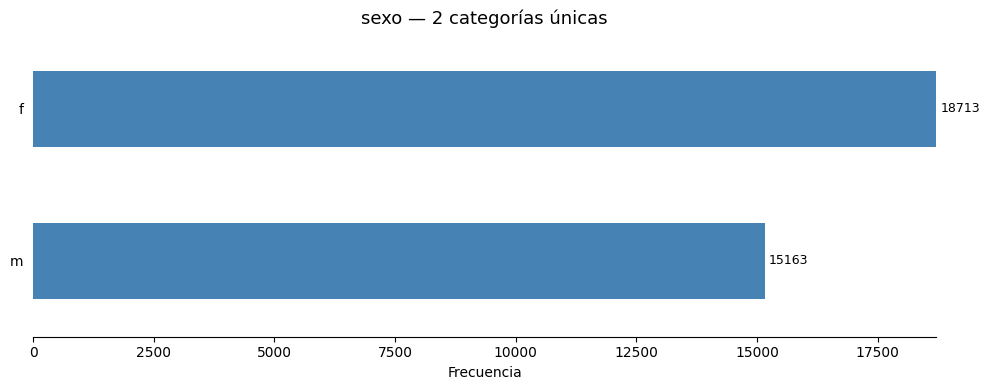

In [207]:
cols_cat = ['rh', 'ciudad', 'sexo']

for col in cols_cat:
    conteo = df_banco_sangre[col].value_counts().sort_values(ascending=True) 
    n = len(conteo)
    
    fig, ax = plt.subplots(figsize=(10, max(4, n * 0.35)))
    conteo.plot(kind='barh', ax=ax, color='steelblue')
    
    ax.set_title(f'{col} — {n} categorías únicas', fontsize=13)
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('')
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    
    # Quitar márgenes
    ax.margins(0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)
    
    plt.tight_layout()
    plt.show()

<div style="background:#f7f7f3; padding:12px 16px; border:0.5px solid #d8d8d4; border-left:3px solid #2e2e2e; border-radius:0 4px 4px 0; font-size:16px; color:#2e2e2e">
    No se encontraron inconsistencias.
</div>

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de datos atipicos
</div>

In [208]:
# Conteo de ceros por columna
cols = df_banco_sangre[df_banco_sangre == 0].count(axis=0)
cols[cols > 0]

Series([], dtype: int64)

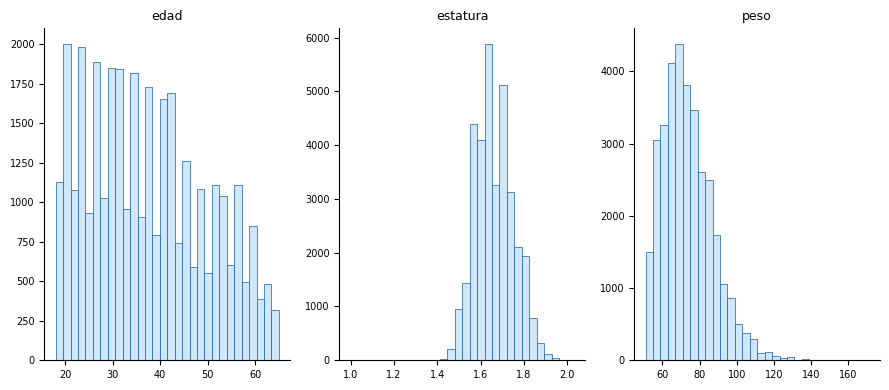

In [209]:
histogramas_numericas(df_banco_sangre)

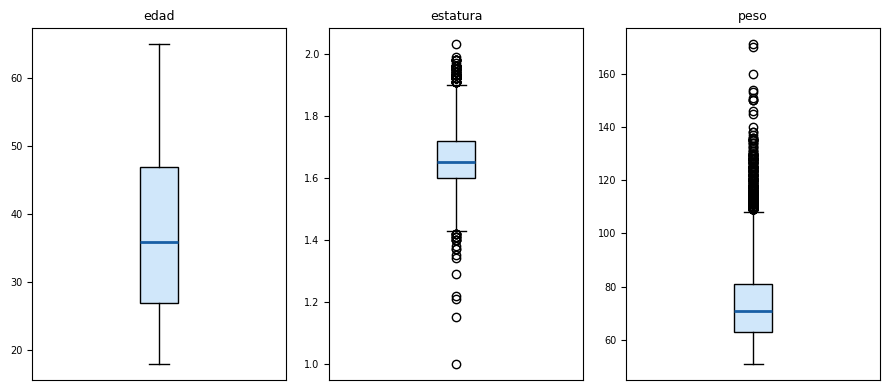

In [210]:
boxplots_numericas(df_banco_sangre)

In [211]:
# Z-score clásico
print("Z-score clásico")
for col in ["edad", "peso", "estatura"]:
    z = np.abs(zscore(df_banco_sangre[col].dropna()))
    print(f"  {col}: {(z > 3).sum()} outliers")

# Z-score modificado
print("\nZ-score modificado")
for col in ["edad", "peso", "estatura"]:
    mad = MAD(threshold=3.5)
    labels = mad.fit(df_banco_sangre[col].dropna().values.reshape(-1, 1)).labels_
    print(f"  {col}: {labels.sum()} outliers")

# IQR
print("\nIQR")
for col in ["edad", "peso", "estatura"]:
    Q1 = df_banco_sangre[col].quantile(0.25)
    Q3 = df_banco_sangre[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df_banco_sangre[col] < Q1 - 1.5 * IQR) |
         (df_banco_sangre[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {n} outliers")

Z-score clásico
  edad: 0 outliers
  peso: 306 outliers
  estatura: 48 outliers

Z-score modificado
  edad: 0 outliers
  peso: 201 outliers
  estatura: 15 outliers

IQR
  edad: 0 outliers
  peso: 540 outliers
  estatura: 111 outliers


In [212]:
mask = np.ones(len(df_banco_sangre), dtype=bool)

for col in ["peso", "estatura"]:
    mad = MAD(threshold=3.5)
    col_data = df_banco_sangre[col].dropna()
    labels = mad.fit(col_data.values.reshape(-1, 1)).labels_
    # Usar posiciones en vez de índices
    outlier_positions = np.where(labels == 1)[0]
    mask[outlier_positions] = False

df_banco_sangre = df_banco_sangre.iloc[mask]
print(f"Registros restantes: {len(df_banco_sangre):,}")

Registros restantes: 33,660


<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Manejo de datos faltantes
</div>

In [213]:
total = len(df_banco_sangre)
missing = df_banco_sangre.isna().sum()

pd.DataFrame({
    "Faltantes": missing,
    "%": (missing / total * 100).round(1)
}).sort_values("Faltantes", ascending=False)

,Faltantes,%
barrio,7588,22.5
rh,41,0.1
estatura,37,0.1
fecha_extraccion,0,0.0
ciudad,0,0.0
edad,0,0.0
peso,0,0.0
sexo,0,0.0


In [214]:
df_banco_sangre = df_banco_sangre.dropna(subset=["rh", "estatura"])

<Axes: >

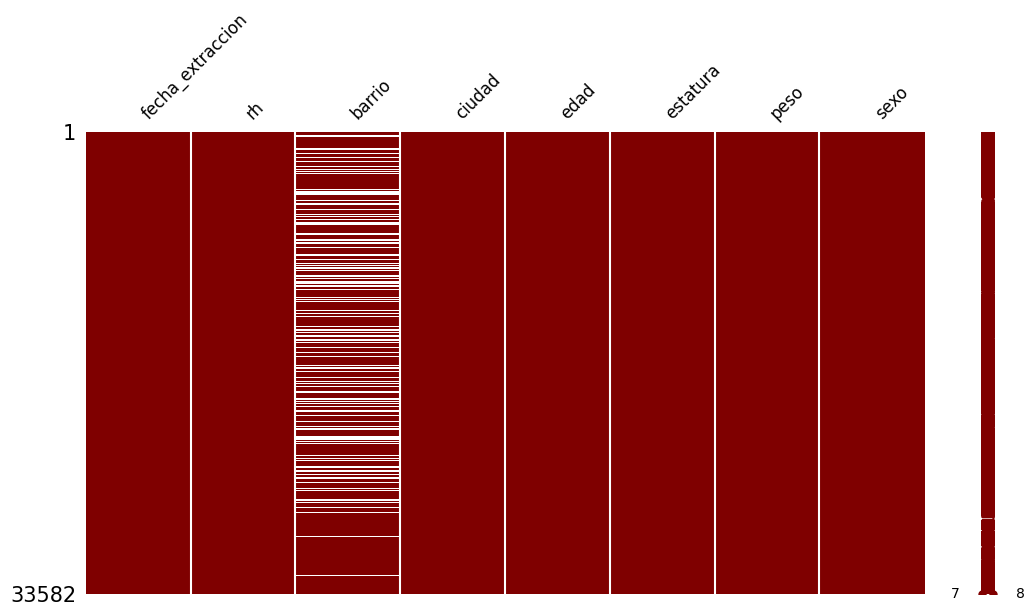

In [215]:
sorted_df = df_banco_sangre.sort_values('fecha_extraccion')
msno.matrix(sorted_df, figsize=(12, 6), fontsize=12, color=[0.5, 0, 0])

In [216]:
df_banco_sangre["barrio"] = df_banco_sangre["barrio"].fillna("desconocido")

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Ingeniería de Características 
</div>

In [217]:
df_banco_sangre["estatura"]

1        1.74
3        1.60
5        1.66
6        1.50
7        1.63
         ... 
35835    1.59
35836    1.57
35837    1.58
35838    1.65
35839    1.81
Name: estatura, Length: 33582, dtype: float64

In [218]:
# Calcular IMC
df_banco_sangre["imc"] = (df_banco_sangre["peso"] / (df_banco_sangre["estatura"] ** 2)).round(2)

# Eliminar estatura
df_banco_sangre = df_banco_sangre.drop(columns=["estatura"])

<div style="background:#f0f0eb; color:#2e2e2e; padding:9px 18px; letter-spacing:2px; text-transform:uppercase; font-size:17px; font-weight:bold; border-left:3px solid #2e2e2e">
    Resultado Limpieza
</div>

In [219]:
explorar_df("Banco", df_banco_sangre)


Banco  —  33,582 filas × 8 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
fecha_extraccion,object,0,0.0,2020-02-01,2020-02-01,2020-02-01,2020-02-01,2020-02-01
rh,str,0,0.0,0+,0+,0-,0-,0+
barrio,str,0,0.0,20_de_julio,20_de_julio,cataluna,villatina,laureles
ciudad,str,0,0.0,medellin,medellin,medellin,medellin,medellin
edad,int64,0,0.0,43,44,58,59,61
peso,float64,0,0.0,80.0,86.0,81.0,57.0,63.0
sexo,str,0,0.0,m,f,f,f,f
imc,float64,0,0.0,26.42,33.59,29.39,25.33,23.71
